# 02 · Portfolio benchmarking: EUI, carbon & water

**Question.** How do large-format stores compare on energy, carbon and water intensity, which are improving, and how big is the gap between the best and worst?

**Data.** Clean annual LL84 rows from notebook 01 (exclusion-grade quality issues removed), CY2019–2024. Core cohort = *Retail Store* + *Wholesale Club/Supercenter*; grocery and malls are comparison groups.

**Method.** Site and weather-normalised EUI in kBtu/ft² and kWh/m² (the unit used in Europe and India), quartile benchmarking, **paired** year-over-year change (same stores in both years, so changes in the cohort's make-up don't fake a trend), a simple age regression, and Scope 1 + 2 emissions recomputed with cited factors plus an India-grid sensitivity.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from IPython.display import Markdown, display

from wattwise import io, kpis, carbon, viz

warnings.filterwarnings("ignore", category=FutureWarning)
np.random.seed(io.assumptions()["seed"])
pd.set_option("display.float_format", lambda v: f"{v:,.1f}")
viz.use_style()

a = io.load("annual_clean")
bb = a[a.cohort == "Big-box retail"].copy()
LATEST = int(a.year.max())
print(f"Clean rows: {len(a):,} | big-box rows: {len(bb):,} | latest year: {LATEST}")

Clean rows: 2,996 | big-box rows: 1,787 | latest year: 2024


## 1 · How intensive are retail formats? (latest year)

In [2]:
latest = a[a.year == LATEST].copy()
order = latest.groupby("property_type").site_eui_kwh_m2.median().sort_values().index.tolist()
summary = latest.groupby("property_type").agg(
    stores=("property_id", "nunique"),
    median_site_eui_kbtu_ft2=("site_eui", "median"),
    median_site_eui_kwh_m2=("site_eui_kwh_m2", "median"),
    median_wn_eui_kwh_m2=("wn_site_eui_kwh_m2", "median"),
    median_ghg_kg_m2=("ghg_kg_m2", "median"),
).loc[order]
summary

,stores,median_site_eui_kbtu_ft2,median_site_eui_kwh_m2,median_wn_eui_kwh_m2,median_ghg_kg_m2
property_type,,,,,
Wholesale Club/Supercenter,16,53.6,169.1,177.9,55.1
Retail Store,300,63.0,198.6,202.8,65.2
Enclosed Mall,26,88.1,277.9,282.8,94.1
Strip Mall,113,98.7,311.4,316.1,93.1
Supermarket/Grocery Store,104,190.5,600.9,614.2,193.7


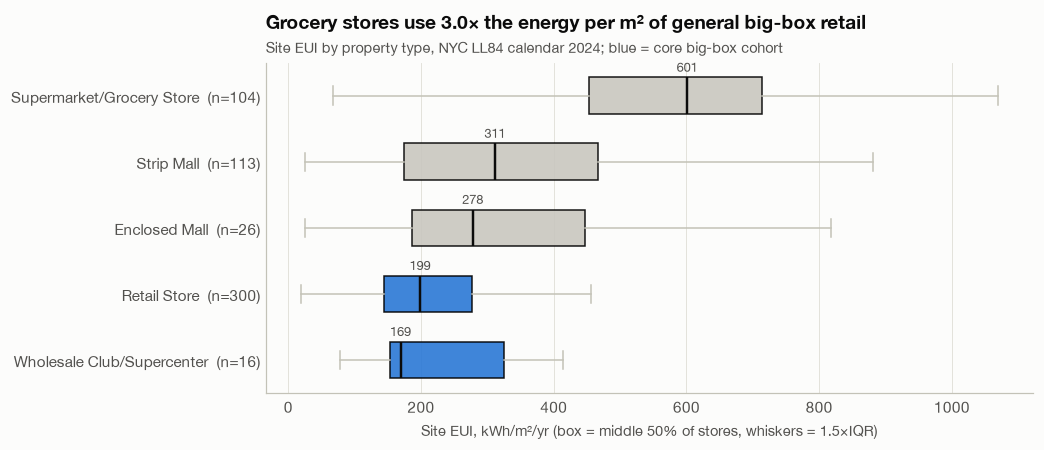

In [3]:
fig, ax = plt.subplots(figsize=(9, 3.9))
data = [latest.loc[latest.property_type == t, "site_eui_kwh_m2"].dropna() for t in order]
colors = [viz.BLUE if t in io.BIG_BOX_TYPES else viz.CONTEXT for t in order]
bp = ax.boxplot(data, orientation="horizontal", widths=0.55, patch_artist=True, showfliers=False,
                medianprops=dict(color=viz.INK, linewidth=1.6), whiskerprops=dict(color=viz.AXIS),
                capprops=dict(color=viz.AXIS))
for patch, c in zip(bp["boxes"], colors):
    patch.set_facecolor(c); patch.set_alpha(0.9)
for i, d in enumerate(data, start=1):
    ax.text(d.median(), i + 0.36, f"{d.median():,.0f}", ha="center", fontsize=8.5, color=viz.INK_2)
ax.set_yticks(range(1, len(order) + 1), [f"{t}  (n={len(d)})" for t, d in zip(order, data)])
ax.set_xlabel("Site EUI, kWh/m²/yr (box = middle 50% of stores, whiskers = 1.5×IQR)")
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
gro = summary.loc["Supermarket/Grocery Store", "median_site_eui_kwh_m2"]
ret = summary.loc["Retail Store", "median_site_eui_kwh_m2"]
viz.title(ax, f"Grocery stores use {gro / ret:.1f}× the energy per m² of general big-box retail",
          f"Site EUI by property type, NYC LL84 calendar {LATEST}; blue = core big-box cohort")
viz.save(fig, "02_eui_by_type")
plt.show()

## 2 · Trend: what happened to big-box intensity 2019 → 2024?
The plain cohort median moves when stores join or leave. The robust view is a **balanced panel** of stores that report in every year.

In [4]:
yrs = sorted(bb.year.unique())
panel_ids = bb.groupby("property_id").year.nunique()
panel_ids = panel_ids[panel_ids == len(yrs)].index
panel = bb[bb.property_id.isin(panel_ids)]
trend = pd.DataFrame({
    "all stores (median)": bb.groupby("year").site_eui_kwh_m2.median(),
    "balanced panel (median)": panel.groupby("year").site_eui_kwh_m2.median(),
    "balanced panel, weather-normalised": panel.groupby("year").wn_site_eui_kwh_m2.median(),
    "panel p25": panel.groupby("year").site_eui_kwh_m2.quantile(0.25),
    "panel p75": panel.groupby("year").site_eui_kwh_m2.quantile(0.75),
})
print(f"Balanced panel: {len(panel_ids)} big-box stores reporting in all {len(yrs)} years")
trend

Balanced panel: 116 big-box stores reporting in all 6 years


,all stores (median),balanced panel (median),"balanced panel, weather-normalised",panel p25,panel p75
year,,,,,
2019,228.7,235.2,238.2,162.1,299.4
2020,191.2,194.5,204.9,155.5,251.5
2021,207.7,214.2,219.9,148.3,280.4
2022,206.0,212.9,215.5,159.1,270.2
2023,192.7,200.3,218.9,145.4,284.8
2024,198.1,211.0,217.8,148.7,285.3


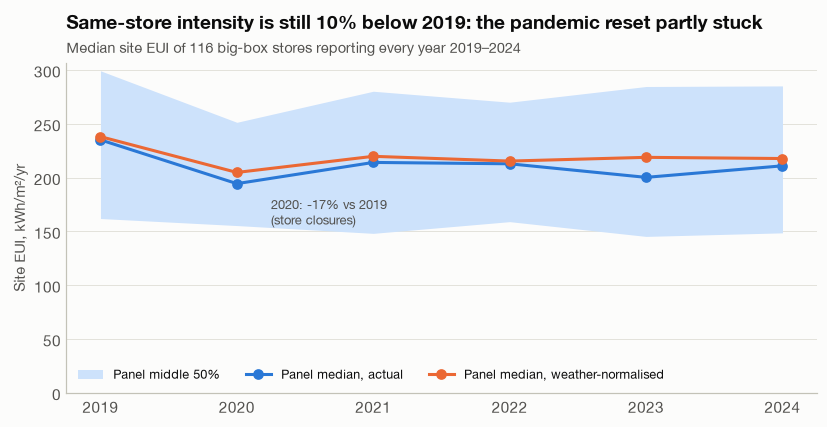

In [5]:
fig, ax = plt.subplots(figsize=(8.8, 3.9))
ax.fill_between(trend.index, trend["panel p25"], trend["panel p75"], color=viz.BLUE_RAMP[0], label="Panel middle 50%")
ax.plot(trend.index, trend["balanced panel (median)"], color=viz.BLUE, marker="o", label="Panel median, actual")
ax.plot(trend.index, trend["balanced panel, weather-normalised"], color=viz.ORANGE, marker="o", label="Panel median, weather-normalised")
base, covid, last = trend.loc[2019, "balanced panel (median)"], trend.loc[2020, "balanced panel (median)"], trend.loc[LATEST, "balanced panel (median)"]
ax.annotate(f"2020: {covid / base - 1:+.0%} vs 2019\n(store closures)", (2020, covid), xytext=(2020.25, covid - 38),
            fontsize=8.5, color=viz.INK_2, arrowprops=dict(arrowstyle="-", color=viz.AXIS))
ax.set_ylabel("Site EUI, kWh/m²/yr")
ax.set_ylim(0, None)
ax.legend(loc="lower left", ncols=3, fontsize=8.3)
viz.title(ax, f"Same-store intensity is still {abs(last / base - 1):.0%} below 2019: the pandemic reset partly stuck",
          f"Median site EUI of {len(panel_ids)} big-box stores reporting every year {yrs[0]}–{yrs[-1]}")
viz.save(fig, "02_trend_panel")
plt.show()

### Most and least improved stores (weather-normalised EUI, 2022 → latest)
Weather-normalised EUI strips out a hot or cold year. Comparing 2022 with the latest year gives the post-pandemic operating trend. Store names are anonymised.

In [6]:
pair_from = 2022
p = bb[bb.year.isin([pair_from, LATEST])].pivot_table(index="property_id", columns="year", values="wn_site_eui_kwh_m2")
p = p.dropna()
p["change_pct"] = (p[LATEST] / p[pair_from] - 1) * 100
# drop implausible jumps (likely meter / floor-area re-baselining) from the ranking
p = p[p["change_pct"].abs() < 60]
p = p.sort_values("change_pct")
p["store"] = [f"Store {i:03d}" for i in range(1, len(p) + 1)]
improved, worsened = p.head(10), p.tail(10)
print(f"Paired stores {pair_from}→{LATEST}: {len(p)}; median change {p.change_pct.median():+.1f}%; "
      f"{(p.change_pct < 0).mean():.0%} improved")
pd.concat([improved.assign(group="most improved"), worsened.assign(group="least improved")])[["group", "store", pair_from, LATEST, "change_pct"]]

Paired stores 2022→2024: 161; median change -3.4%; 60% improved


year,group,store,2022,2024,change_pct
property_id,,,,,
6045317,most improved,Store 001,266.9,123.0,-53.9
3962142,most improved,Store 002,327.8,179.8,-45.1
10536715,most improved,Store 003,122.4,69.1,-43.6
7097728,most improved,Store 004,276.0,163.1,-40.9
3119998,most improved,Store 005,157.4,98.1,-37.7
6610262,most improved,Store 006,160.3,100.0,-37.6
6410264,most improved,Store 007,198.4,126.5,-36.2
12063327,most improved,Store 008,412.6,278.2,-32.6
6698367,most improved,Store 009,152.4,108.5,-28.8


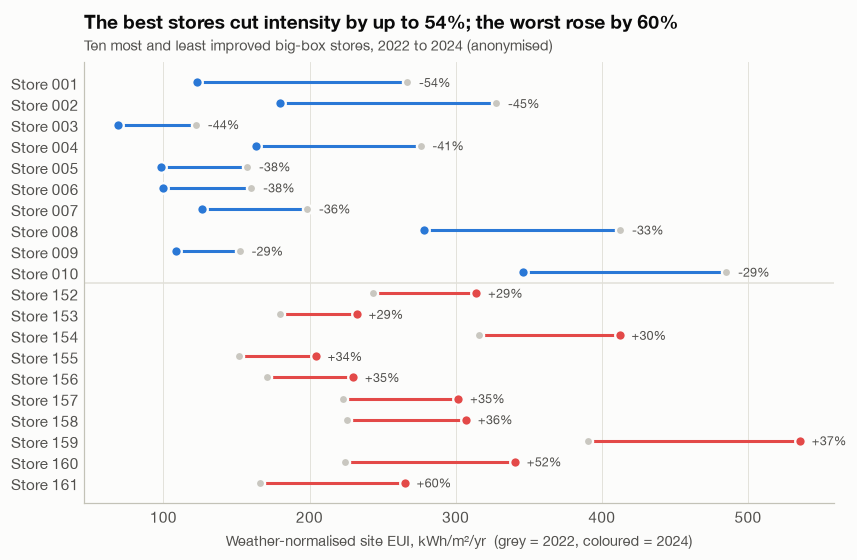

In [7]:
fig, ax = plt.subplots(figsize=(8.8, 5.2))
show = pd.concat([improved, worsened])
ypos = np.arange(len(show))[::-1]
for y, (_, r) in zip(ypos, show.iterrows()):
    c = viz.BLUE if r.change_pct < 0 else viz.RED
    ax.plot([r[pair_from], r[LATEST]], [y, y], color=c, linewidth=2, solid_capstyle="round")
    ax.scatter(r[pair_from], y, color=viz.CONTEXT, s=36, zorder=3, edgecolor=viz.SURFACE, linewidth=1.5)
    ax.scatter(r[LATEST], y, color=c, s=48, zorder=3, edgecolor=viz.SURFACE, linewidth=1.5)
    ax.text(max(r[pair_from], r[LATEST]) + 8, y, f"{r.change_pct:+.0f}%", va="center", fontsize=8.2, color=viz.INK_2)
ax.set_yticks(ypos, show.store)
ax.axhline(9.5, color=viz.GRID, linewidth=1)
ax.set_xlabel(f"Weather-normalised site EUI, kWh/m²/yr  (grey = {pair_from}, coloured = {LATEST})")
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
viz.title(ax, f"The best stores cut intensity by up to {-improved.change_pct.min():.0f}%; the worst rose by {worsened.change_pct.max():.0f}%",
          f"Ten most and least improved big-box stores, {pair_from} to {LATEST} (anonymised)")
viz.save(fig, "02_improvers")
plt.show()

## 3 · Quartile benchmarking (latest year)
Top 25% = lowest EUI. This is the internal benchmark a portfolio energy team uses to pick where to send engineers first.

In [8]:
bl = bb[bb.year == LATEST].dropna(subset=["site_eui_kwh_m2"]).copy()
bl["quartile"] = kpis.quartile_label(bl["site_eui_kwh_m2"])
qt = bl.groupby("quartile").agg(stores=("property_id", "size"), median_eui_kwh_m2=("site_eui_kwh_m2", "median"),
                                floor_area_m2=("gfa_m2", "sum"), electricity_gwh=("elec_kwh", lambda s: s.sum() / 1e6),
                                ghg_kt=("ghg_t", lambda s: s.sum() / 1e3)).loc[["Top 25%", "Middle 50%", "Bottom 25%"]]
ratio_bq_tq = qt.loc["Bottom 25%", "median_eui_kwh_m2"] / qt.loc["Top 25%", "median_eui_kwh_m2"]
qt

,stores,median_eui_kwh_m2,floor_area_m2,electricity_gwh,ghg_kt
quartile,,,,,
Top 25%,79,95.9,"716,411.0",51.9,24.6
Middle 50%,158,198.1,"1,515,397.4",220.9,105.2
Bottom 25%,79,381.7,"701,975.8",154.9,77.5


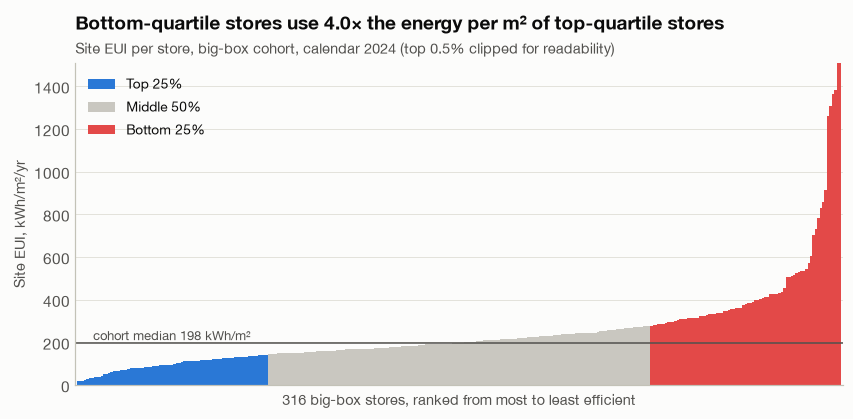

In [9]:
fig, ax = plt.subplots(figsize=(9, 3.8))
s = bl.sort_values("site_eui_kwh_m2").reset_index(drop=True)
cmap = {"Top 25%": viz.BLUE, "Middle 50%": viz.CONTEXT, "Bottom 25%": viz.RED}
ax.bar(s.index, s.site_eui_kwh_m2, color=s.quartile.map(cmap), width=1.0, linewidth=0)
med = s.site_eui_kwh_m2.median()
ax.axhline(med, color=viz.INK_2, linewidth=1)
ax.text(len(s) * 0.02, med + 12, f"cohort median {med:,.0f} kWh/m²", fontsize=8.5, color=viz.INK_2)
ax.set_xlim(-1, len(s))
ax.set_xticks([])
ax.set_xlabel(f"{len(s)} big-box stores, ranked from most to least efficient")
ax.set_ylabel("Site EUI, kWh/m²/yr")
ax.set_ylim(0, s.site_eui_kwh_m2.quantile(0.995) * 1.05)
for k, c in cmap.items():
    ax.bar(0, 0, color=c, label=k)
ax.legend(loc="upper left")
viz.title(ax, f"Bottom-quartile stores use {ratio_bq_tq:.1f}× the energy per m² of top-quartile stores",
          f"Site EUI per store, big-box cohort, calendar {LATEST} (top 0.5% clipped for readability)")
viz.save(fig, "02_quartiles")
plt.show()

## 4 · Water, fuel mix and carbon intensity

In [10]:
cols = {"water_l_m2": "Water, L/m²/yr", "elec_share": "Electricity share of site energy", "ghg_kg_m2": "GHG, kgCO₂e/m²/yr"}
desc = bl[list(cols)].describe(percentiles=[0.25, 0.5, 0.75]).T.rename(index=cols)[["count", "25%", "50%", "75%"]]
desc

,count,25%,50%,75%
"Water, L/m²/yr",182.0,147.3,359.9,846.6
Electricity share of site energy,301.0,0.5,0.7,0.9
"GHG, kgCO₂e/m²/yr",316.0,44.3,64.1,93.5


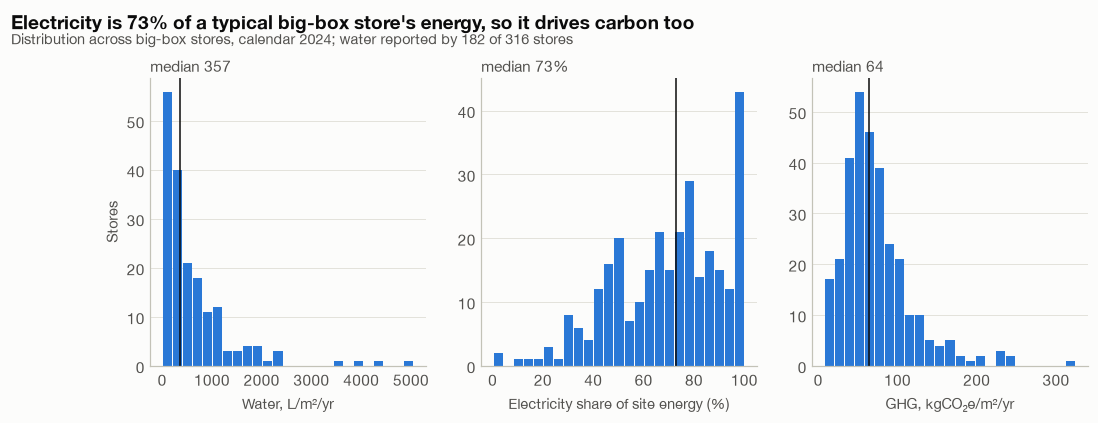

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))
for ax, (c, lab) in zip(axes, cols.items()):
    v = bl[c].dropna()
    v = v[v.between(v.quantile(0.01), v.quantile(0.99))]
    ax.hist(v * (100 if c == "elec_share" else 1), bins=25, color=viz.BLUE, rwidth=0.9)
    m = v.median() * (100 if c == "elec_share" else 1)
    ax.axvline(m, color=viz.INK, linewidth=1)
    ax.set_title(f"median {m:,.0f}{'%' if c == 'elec_share' else ''}", fontsize=10, fontweight="normal", color=viz.INK_2, pad=4)
    ax.set_xlabel(lab + (" (%)" if c == "elec_share" else ""))
axes[0].set_ylabel("Stores")
elec_med = bl.elec_share.median()
fig.suptitle(f"Electricity is {elec_med:.0%} of a typical big-box store's energy, so it drives carbon too",
             x=0.01, ha="left", fontsize=12.5, fontweight="bold", y=1.06)
fig.text(0.01, 0.97, f"Distribution across big-box stores, calendar {LATEST}; water reported by {bl.water_l_m2.notna().sum()} of {len(bl)} stores",
         color=viz.INK_2, fontsize=9.5)
viz.save(fig, "02_water_mix_ghg")
plt.show()

## 5 · Does ENERGY STAR score track EUI? Does building age explain it?

In [12]:
es = bl.dropna(subset=["energy_star", "site_eui_kwh_m2"])
age = bl.dropna(subset=["year_built", "site_eui_kwh_m2"])
age = age[age.year_built.between(1850, LATEST)]
X = sm.add_constant(age["year_built"])
age_fit = sm.OLS(age["site_eui_kwh_m2"], X).fit()
es_fit = sm.OLS(es["site_eui_kwh_m2"], sm.add_constant(es["energy_star"])).fit()
rho = es[["energy_star", "site_eui_kwh_m2"]].corr(method="spearman").iloc[0, 1]
print(f"ENERGY STAR vs EUI: n={len(es)}, Spearman rho={rho:.2f}, R²={es_fit.rsquared:.2f}")
print(f"Year built vs EUI:  n={len(age)}, R²={age_fit.rsquared:.3f}, slope={age_fit.params['year_built']:+.2f} kWh/m² per year, p={age_fit.pvalues['year_built']:.3f}")

ENERGY STAR vs EUI: n=221, Spearman rho=-0.83, R²=0.42
Year built vs EUI:  n=316, R²=0.002, slope=-0.30 kWh/m² per year, p=0.438


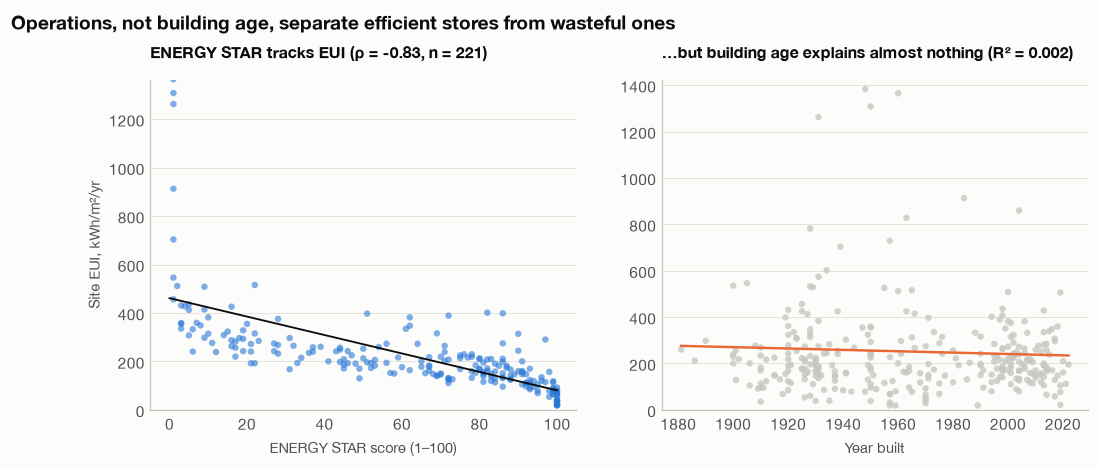

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.9))
ax = axes[0]
ax.scatter(es.energy_star, es.site_eui_kwh_m2, s=18, color=viz.BLUE, alpha=0.6, edgecolor="none")
xs = np.linspace(0, 100, 50)
ax.plot(xs, es_fit.params["const"] + es_fit.params["energy_star"] * xs, color=viz.INK, linewidth=1.2)
ax.set_xlabel("ENERGY STAR score (1–100)"); ax.set_ylabel("Site EUI, kWh/m²/yr")
ax.set_ylim(0, es.site_eui_kwh_m2.quantile(0.99) * 1.05)
ax.set_title(f"ENERGY STAR tracks EUI (ρ = {rho:.2f}, n = {len(es)})", fontsize=10.5)
ax = axes[1]
ax.scatter(age.year_built, age.site_eui_kwh_m2, s=18, color=viz.CONTEXT, alpha=0.8, edgecolor="none")
xs = np.linspace(age.year_built.min(), age.year_built.max(), 50)
ax.plot(xs, age_fit.params["const"] + age_fit.params["year_built"] * xs, color=viz.ORANGE, linewidth=1.6)
ax.set_xlabel("Year built"); ax.set_ylim(0, age.site_eui_kwh_m2.quantile(0.99) * 1.05)
ax.set_title(f"…but building age explains almost nothing (R² = {age_fit.rsquared:.3f})", fontsize=10.5)
fig.suptitle("Operations, not building age, separate efficient stores from wasteful ones", x=0.01, ha="left",
             fontsize=12.5, fontweight="bold", y=1.04)
viz.save(fig, "02_energystar_age")
plt.show()

## 6 · Carbon: Scope 1 + 2 with cited factors, and the India sensitivity
Scope 1 = natural gas × EPA Hub factor. Scope 2 (location-based) = electricity × eGRID2023 NYCW factor. The **sensitivity** re-runs the same stores on India's grid (CEA v21, FY2024-25) to show what the same operation would emit there. *Factors are assumptions; see `config/assumptions.yaml`.*

In [14]:
f = carbon.factors()
em = carbon.emissions_table(bl)
tot = em[["scope1_t", "scope2_us_t", "scope2_india_t", "ghg_t"]].sum()
comparison = pd.DataFrame({
    "tCO2e": [tot.scope1_t, tot.scope2_us_t, tot.scope1_t + tot.scope2_us_t, tot.ghg_t, tot.scope2_india_t, tot.scope1_t + tot.scope2_india_t],
}, index=["Scope 1 (gas)", "Scope 2 (NYC grid, eGRID NYCW)", "Total, our calculation", "Total, city-reported (Portfolio Manager)",
          "Scope 2 if on India grid (CEA v21)", "Total if on India grid"])
india_uplift = tot.scope2_india_t / tot.scope2_us_t - 1
print(f"Grid factors: NYC {f['us_grid']:.3f} vs India {f['india_grid']:.3f} kgCO2e/kWh (assumption)")
comparison

Grid factors: NYC 0.393 vs India 0.710 kgCO2e/kWh (assumption)


,tCO2e
Scope 1 (gas),"30,634.8"
"Scope 2 (NYC grid, eGRID NYCW)","167,982.0"
"Total, our calculation","198,616.8"
"Total, city-reported (Portfolio Manager)","207,330.8"
Scope 2 if on India grid (CEA v21),"303,710.8"
Total if on India grid,"334,345.6"


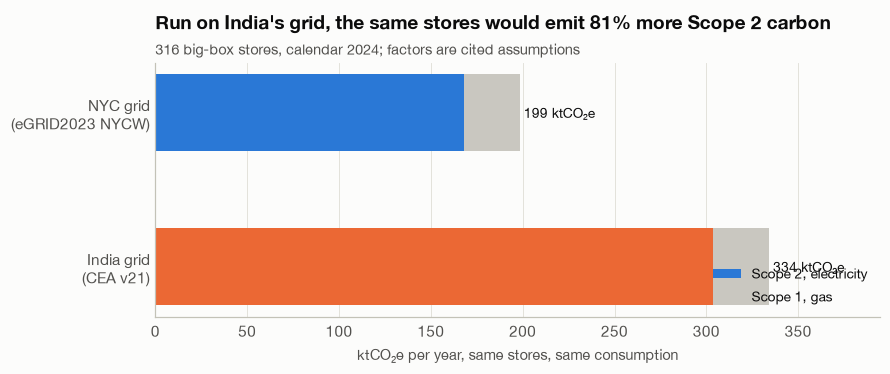

In [15]:
fig, ax = plt.subplots(figsize=(8.5, 3.0))
labels = ["NYC grid\n(eGRID2023 NYCW)", "India grid\n(CEA v21)"]
s1 = [tot.scope1_t / 1e3] * 2
s2 = [tot.scope2_us_t / 1e3, tot.scope2_india_t / 1e3]
ax.barh(labels, s2, color=[viz.BLUE, viz.ORANGE], height=0.5, label="Scope 2, electricity")
ax.barh(labels, s1, left=s2, color=viz.CONTEXT, height=0.5, label="Scope 1, gas")
for i, (a2, a1) in enumerate(zip(s2, s1)):
    ax.text(a2 + a1 + 2, i, f"{a2 + a1:,.0f} ktCO₂e", va="center", fontsize=9)
ax.set_xlabel("ktCO₂e per year, same stores, same consumption")
ax.invert_yaxis(); ax.grid(axis="x"); ax.grid(axis="y", visible=False)
ax.legend(loc="lower right")
ax.set_xlim(0, (max(s2) + s1[0]) * 1.18)
viz.title(ax, f"Run on India's grid, the same stores would emit {india_uplift:.0%} more Scope 2 carbon",
          f"{len(bl)} big-box stores, calendar {LATEST}; factors are cited assumptions")
viz.save(fig, "02_india_sensitivity")
plt.show()

In [16]:
bl[["property_id", "year", "property_type", "gfa_m2", "site_eui_kwh_m2", "wn_site_eui_kwh_m2", "elec_kwh", "gas_kbtu", "ghg_t", "quartile", "dq_score"]].to_parquet(io.PROCESSED / "benchmark_latest.parquet", index=False)
median_eui = bl.site_eui_kwh_m2.median()
bq = bl[bl.quartile == "Bottom 25%"]
# energy if each bottom-quartile store came down to the cohort median (electricity share kept)
bq_excess_kwh_m2 = (bq.site_eui_kwh_m2 - median_eui).clip(lower=0)
bq_saving_site_kwh = float((bq_excess_kwh_m2 * bq.gfa_m2).sum())
bq_top5 = float(((bq_excess_kwh_m2 * bq.gfa_m2).nlargest(5).sum()) / bq_saving_site_kwh)
bq_saving_elec_kwh = float((bq_excess_kwh_m2 * bq.gfa_m2 * bq.elec_share.fillna(bl.elec_share.median()).clip(0, 1)).sum())
io.save_result("02_benchmark", {
    "latest_year": LATEST,
    "big_box_stores_latest": len(bl),
    "median_site_eui_kwh_m2": float(median_eui),
    "median_site_eui_kbtu_ft2": float(bl.site_eui.median()),
    "grocery_vs_retail_ratio": float(gro / ret),
    "panel_stores": len(panel_ids),
    "panel_change_vs_2019": float(last / base - 1),
    "panel_covid_change": float(covid / base - 1),
    "paired_stores_2022_latest": len(p),
    "paired_median_change_pct": float(p.change_pct.median()),
    "paired_share_improved": float((p.change_pct < 0).mean()),
    "best_improvement_pct": float(improved.change_pct.min()),
    "worst_increase_pct": float(worsened.change_pct.max()),
    "bottom_vs_top_quartile_ratio": float(ratio_bq_tq),
    "top_quartile_median": float(qt.loc["Top 25%", "median_eui_kwh_m2"]),
    "bottom_quartile_median": float(qt.loc["Bottom 25%", "median_eui_kwh_m2"]),
    "bottom_quartile_stores": int(qt.loc["Bottom 25%", "stores"]),
    "bottom_quartile_to_median_site_kwh": bq_saving_site_kwh,
    "bottom_quartile_to_median_elec_kwh": bq_saving_elec_kwh,
    "bottom_quartile_top5_share": bq_top5,
    "electricity_share_median": float(elec_med),
    "water_median_l_m2": float(bl.water_l_m2.median()),
    "ghg_median_kg_m2": float(bl.ghg_kg_m2.median()),
    "energy_star_rho": float(rho),
    "age_r2": float(age_fit.rsquared),
    "age_p": float(age_fit.pvalues["year_built"]),
    "scope1_t": float(tot.scope1_t), "scope2_us_t": float(tot.scope2_us_t), "scope2_india_t": float(tot.scope2_india_t),
    "city_reported_total_t": float(tot.ghg_t),
    "india_scope2_uplift": float(india_uplift),
    "cohort_electricity_gwh": float(bl.elec_kwh.sum() / 1e6),
    "cohort_floor_area_m2": float(bl.gfa_m2.sum()),
})

In [17]:
display(Markdown(f"""
## Key findings
1. **Format matters.** Grocery stores run at {gro / ret:.1f}× the intensity of general retail, mainly refrigeration. Benchmarks must compare like with like.
2. **The pandemic reset stuck.** Among {len(panel_ids)} stores reporting every year, median intensity fell {abs(covid / base - 1):.0%} in 2020 and in {LATEST} is still {abs(last / base - 1):.0%} below 2019.
3. **The gap is the opportunity.** Bottom-quartile stores use **{ratio_bq_tq:.1f}×** the energy per m² of top-quartile stores ({qt.loc['Bottom 25%','median_eui_kwh_m2']:,.0f} vs {qt.loc['Top 25%','median_eui_kwh_m2']:,.0f} kWh/m²). Bringing them to the cohort median is a technical potential of about **{bq_saving_site_kwh / 1e6:,.0f} GWh** of site energy a year (not spread evenly: the five largest contributors are {bq_top5:.0%} of it).
4. **Operations beat age.** Year built explains R² = {age_fit.rsquared:.3f} of EUI. ENERGY STAR score tracks EUI closely (Spearman ρ = {rho:.2f}; higher score, lower EUI), so it works as a quick screen.
5. **Electricity is the lever.** It is {elec_med:.0%} of a typical store's energy. On India's grid (CEA v21) the same consumption would emit {india_uplift:.0%} more Scope 2 carbon, so efficiency is worth far more per kWh there.
"""))


## Key findings
1. **Format matters.** Grocery stores run at 3.0× the intensity of general retail, mainly refrigeration. Benchmarks must compare like with like.
2. **The pandemic reset stuck.** Among 116 stores reporting every year, median intensity fell 17% in 2020 and in 2024 is still 10% below 2019.
3. **The gap is the opportunity.** Bottom-quartile stores use **4.0×** the energy per m² of top-quartile stores (382 vs 96 kWh/m²). Bringing them to the cohort median is a technical potential of about **147 GWh** of site energy a year (not spread evenly: the five largest contributors are 30% of it).
4. **Operations beat age.** Year built explains R² = 0.002 of EUI. ENERGY STAR score tracks EUI closely (Spearman ρ = -0.83; higher score, lower EUI), so it works as a quick screen.
5. **Electricity is the lever.** It is 73% of a typical store's energy. On India's grid (CEA v21) the same consumption would emit 81% more Scope 2 carbon, so efficiency is worth far more per kWh there.
